<a href="https://colab.research.google.com/github/omazevych/python_for_da_tasks/blob/main/Additional_hw_4_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Додаткове завдання з pandas
Вітаю! В цьому завданні будемо працювати з даними з опитування щодо зарплат ІТ спеціалістів на рексурсі DOU від грудня 2022 року. Впевнена, це буде цікаве дослідження, а заразом і практика pandas :)
Цей аналіз може бути корисним людині, яка обирає напрям роботи в ІТ і хоче зрозуміти тенденції. За якісного виконання цього аналізу, цей проєкт можна сміливо додавати у Ваше портфоліо!

1. Зчитайте дані з файлу `2022_dec_raw.csv`. Увага! Тут необхідно використати аргумент `pd.read_csv` `sep=';'`, бо розділювач в даних - крапка з комою.

In [24]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
df = pd.read_csv('drive/MyDrive/Data Analysis/Python/homeworks/2022_dec_raw.csv', sep=';')

2. Які колонки мають дані?

In [26]:
display(df.columns.tolist())

['Timestamp',
 'Ви працюєте зараз в ІТ?',
 'Де ви зараз живете? ',
 'В якій області ви зараз живете?',
 'Зарплата у $$$ за місяць, лише ставка після сплати податків',
 'Ваша стать',
 'Ваш вік',
 'Яка у вас освіта?',
 'Чи є у вас науковий ступінь? ',
 'Знання англійської мови',
 'Оберіть вашу посаду',
 'Ваш тайтл',
 'Ваша спеціалізація',
 'Вкажіть вашу спеціалізацію',
 'Оберіть вашу спеціалізацію',
 'Ваша посада',
 'Оберіть вашу посаду2',
 'Ваша посада3',
 'Ваша посада4',
 'Ваша посада5',
 'Ваша посада6',
 'Ваша посада7',
 'Чи використовуєте ви у своїй роботі мови програмування (одну чи декілька)?',
 'Основна мова програмування',
 'Вкажіть вашу основну спеціалізацію',
 'В якій сфері працюєте?',
 'Тип компанії',
 'Загальний стаж роботи за спеціальністю']

3. Скільки рядків та колонок мають дані? Скільки пропущених значень має кожна з колонок?

In [27]:
print("Розмір DataFrame:", df.shape)
missing_values = df.isna().sum()
print("Пропущені значення по колонках:\n", missing_values)

Розмір DataFrame: (13315, 28)
Пропущені значення по колонках:
 Timestamp                                                                         0
Ви працюєте зараз в ІТ?                                                           0
Де ви зараз живете?                                                               0
В якій області ви зараз живете?                                                1777
Зарплата у $$$ за місяць, лише ставка після сплати податків                      27
Ваша стать                                                                        0
Ваш вік                                                                           0
Яка у вас освіта?                                                                 0
Чи є у вас науковий ступінь?                                                    111
Знання англійської мови                                                           0
Оберіть вашу посаду                                                               0
Ваш тайтл    

4. Які колонки мають всі значення заповненими (не мають дожного None значення)? Виведіть програмно список цих колонок.

In [28]:
full_columns = df.columns[df.notna().all()].tolist()
display("Колонки без пропусків:", full_columns)

'Колонки без пропусків:'

['Timestamp',
 'Ви працюєте зараз в ІТ?',
 'Де ви зараз живете? ',
 'Ваша стать',
 'Ваш вік',
 'Яка у вас освіта?',
 'Знання англійської мови',
 'Оберіть вашу посаду',
 'Ваш тайтл',
 'В якій сфері працюєте?',
 'Тип компанії',
 'Загальний стаж роботи за спеціальністю']

5. Який тип мають колонки в наборі даних? Які з колонок типу object логічно на ваш погляд перетворити на числові колонки?

In [29]:
print(df.dtypes)
object_cols = df.select_dtypes(include='object').columns.tolist()

Timestamp                                                                     object
Ви працюєте зараз в ІТ?                                                       object
Де ви зараз живете?                                                           object
В якій області ви зараз живете?                                               object
Зарплата у $$$ за місяць, лише ставка після сплати податків                   object
Ваша стать                                                                    object
Ваш вік                                                                       object
Яка у вас освіта?                                                             object
Чи є у вас науковий ступінь?                                                  object
Знання англійської мови                                                       object
Оберіть вашу посаду                                                           object
Ваш тайтл                                                        

6. Трансформуйте колонки 'Ваш вік', 'Зарплата у $$$ за місяць, лише ставка після сплати податків' у тип даних float. УВАГА! Перед трансформацією подивіться, які дані містять ці колонки. Аби успішно трансформувати тип даних, треба спочатку привести рядки до того виду, який буде підходити, аби потім рядок зробити типом float.

In [30]:
print(df['Ваш вік'].unique())
print(df['Зарплата у $$$ за місяць, лише ставка після сплати податків'].unique())

def to_float(x):
    if pd.isna(x):
        return None
    # прибрати пробіли, коми, знаки долара
    return float(str(x).replace(',', '').replace('$', '').strip())

df['Ваш вік'] = df['Ваш вік'].apply(to_float)
df['Зарплата у $$$ за місяць, лише ставка після сплати податків'] = df[
    'Зарплата у $$$ за місяць, лише ставка після сплати податків'
].apply(to_float)
print(df[['Ваш вік', 'Зарплата у $$$ за місяць, лише ставка після сплати податків']].head())
print(df.dtypes)


['29' '36' '34' '23' '33' '31' '30' '24' '27' '17' '25' '20' '26' '22'
 '19' '21' '18' '32' '35' '28' '37' '43' '44' '39' '50' '40' '38' '41'
 '45' '42' '49' '46' '47' '48' '55' '63' '58' '53' '54' '51' '56' '60'
 '16' '57' '29,5' '52' '14']
['4000' nan '2500' '500' '2800' '5500' '1400' '1200' '650' '6000' '6600'
 '850' '1000' '1500' '3000' '800' '700' '1100' '7500' '10600' '3300'
 '5000' '2400' '1800' '2100' '4500' '2600' '3600' '3525' '1600' '3200'
 '570' '6500' '4200' '1700' '5320' '5300' '1490' '1250' '2700' '4700'
 '1300' '400' '2000' '1577' '10000' '550' '5600' '950' '3550' '4750'
 '2200' '1850' '5200' '3040' '5100' '2250' '6450' '3500' '1900' '4400'
 '2865' '5350' '3700' '2850' '6150' '680' '2169' '1350' '2222' '2185'
 '2750' '3760' '2300' '200' '4275' '7700' '978' '1710' '1170' '3100'
 '5700' '1863' '2900' '3135' '3400' '4300' '730' '8500' '2240' '7000'
 '3650' '5400' '4800' '3800' '6700' '2920' '4100' '5800' '750' '2811'
 '330' '970' '900' '4250' '16000' '1050' '8300' '600' '2

7. Це завдання з зірочкою! Нам треба транфсформувати колонку Timestamp у тип даних `datetime64[ns]`. Це не так просто як здається на першйий погляд :) Але це реальна ситуація, яка може трапитись при зборі даних в роботі аналітиком.
Я запропоную один зі способів виконати завдання, але ви можете написати по-своєму. Головне - отримати колонку - потрібного типу.
Пропоную наступний алгоритм дій:
    1. Подивитись, які дані містяться в цій колонці. Виведіть перші і останні 5 записів. Чи однаковий формат цих даних? (спойлер: ні, бо інакше все було б просто :))
    2. Нам треба враховуючи різний формат даних перетворити рядок у колонці `Timestamp` на тип `datetime64[ns]`. Як це зробити? Для перетворення рядка на `datetime64` пропоную скористатись `datetime.datetime.strptime`.
    Для цього треба імпортувати бібліотеку `datetime`. Я пропоную написати функцію для обробки кожного окремого рядка, яка враховує довжину рядка і на основі цього застосовує різний формат даних дати.
    Як прописувати формат даних можна переглянути [тут](https://www.w3schools.com/python/python_datetime.asp).
    3. Коли функція для обробки кожного окремого рядка готова, застосуйте її для всіх даних з допомогою методу `apply`.

In [31]:
print("HEAD:")
print(df["Timestamp"].head())

print("\nTAIL:")
print(df["Timestamp"].tail())

HEAD:
0    11.30.2022 10:26:37
1    11.30.2022 10:26:39
2    11.30.2022 10:26:58
3    11.30.2022 10:27:31
4    11.30.2022 10:27:34
Name: Timestamp, dtype: object

TAIL:
13310    01.09.2023 11:01
13311    01.09.2023 11:14
13312    01.09.2023 11:19
13313    01.09.2023 11:28
13314    01.09.2023 11:38
Name: Timestamp, dtype: object


In [32]:
import datetime
def parse_timestamp(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    try:
        # формат: 2024-01-01 12:30:00
        if len(x) == 19 and "-" in x:
            return datetime.datetime.strptime(x, "%Y-%m-%d %H:%M:%S")
        # формат: 01/02/2024 13:00
        elif len(x) == 16 and "/" in x:
            return datetime.datetime.strptime(x, "%d/%m/%Y %H:%M")
        # формат: 2024-01-01
        elif len(x) == 10 and "-" in x:
            return datetime.datetime.strptime(x, "%Y-%m-%d")
        # формат: 03-01-24 14:00
        elif len(x) == 14:
            return datetime.datetime.strptime(x, "%d-%m-%y %H:%M")
        else:
            return None
    except:
        return None
df["Timestamp"] = df["Timestamp"].apply(parse_timestamp)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
print("\nТип колонки:")
print(df["Timestamp"].dtype)
print("\nКількість не розпізнаних дат:")
print(df["Timestamp"].isna().sum())
print("\nПісля трансформації:")
print(df["Timestamp"].head())


Тип колонки:
datetime64[ns]

Кількість не розпізнаних дат:
13315

Після трансформації:
0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: Timestamp, dtype: datetime64[ns]


8. Для колонок типу даних object (які такими лишились після всіх наших трансформацій) виведіть кількість унікальних значень.

In [33]:
object_cols = df.select_dtypes(include="object").columns
print(object_cols)
for col in object_cols:
    print(f"\nКолонка: {col}")
    print("Кількість унікальних значень:", df[col].nunique())

Index(['Ви працюєте зараз в ІТ?', 'Де ви зараз живете? ',
       'В якій області ви зараз живете?', 'Ваша стать', 'Яка у вас освіта?',
       'Чи є у вас науковий ступінь? ', 'Знання англійської мови',
       'Оберіть вашу посаду', 'Ваш тайтл', 'Ваша спеціалізація',
       'Вкажіть вашу спеціалізацію', 'Оберіть вашу спеціалізацію',
       'Ваша посада', 'Оберіть вашу посаду2', 'Ваша посада3', 'Ваша посада4',
       'Ваша посада5', 'Ваша посада6', 'Ваша посада7',
       'Чи використовуєте ви у своїй роботі мови програмування (одну чи декілька)?',
       'Основна мова програмування', 'Вкажіть вашу основну спеціалізацію',
       'В якій сфері працюєте?', 'Тип компанії',
       'Загальний стаж роботи за спеціальністю'],
      dtype='object')

Колонка: Ви працюєте зараз в ІТ?
Кількість унікальних значень: 5

Колонка: Де ви зараз живете? 
Кількість унікальних значень: 2

Колонка: В якій області ви зараз живете?
Кількість унікальних значень: 23

Колонка: Ваша стать
Кількість унікальних значен

9. Для колонок типу даних object виведіть топ 10 найбільш частих значень з кількістю рядків, в яких це значення зустрічається. Зробіть це для кожної колонки окремо. Наприклад, в циклі.  
Що цікавого бачите? Які висновки можна зробити? Що особисто Вас вразило?

In [34]:
for col in object_cols:
    print(f"\n ТОП значень для колонки: {col}")
    print(df[col].value_counts().head(10))


 ТОП значень для колонки: Ви працюєте зараз в ІТ?
Ви працюєте зараз в ІТ?
Так, працюю full-time      12643
Ні, тимчасово не працюю      380
Так, працюю part-time        152
Так, я фрилансер             115
Інше                          25
Name: count, dtype: int64

 ТОП значень для колонки: Де ви зараз живете? 
Де ви зараз живете? 
В Україні                                                      11587
За кордоном (переїхали через війну, але планую повернутися)     1728
Name: count, dtype: int64

 ТОП значень для колонки: В якій області ви зараз живете?
В якій області ви зараз живете?
Київ чи область                4411
Львів чи область               2353
Дніпро чи область               751
Івано-Франківськ чи область     478
Вінниця чи область              447
Одеса чи область                443
Харків чи область               355
Полтава чи область              252
Черкаси чи область              232
Хмельницький чи область         230
Name: count, dtype: int64

 ТОП значень для колонк

більшість кандидатів зі стажем 1-3 роки з середнім рівнем англійської. Основні типи компаній аутсорсингові та продуктові. Топ-3 мови програмування JavaScript, Java, Python. Більшість респонденів чоловіки з Київської та Львівської областей.

10. Виведіть медіанну (медіана - це значення, менше якого є рівно 50% вибірки і більше якого є теж рівно 50% вибірки)
ЗП (Зарплата у $$$) для кожного рівня знання англійської. Які висновки можна зробити?

In [35]:
median_salary = (
    df.groupby("Знання англійської мови")
    .agg(median_salary=("Зарплата у $$$ за місяць, лише ставка після сплати податків", "median"))
    .sort_values("median_salary")
)
display(median_salary)

,median_salary
Знання англійської мови,
Elementary,1155.0
Pre-Intermediate,1416.5
Intermediate,2150.0
Upper-Intermediate,3300.0
Advanced,3500.0


Основний висновок: рівень заробітньої платні напряму залежить від рівня володіння англійською мовою.

11. Є така штука як сортування значень категоріальної змінної. Нам це зараз стане в нагоді, адже рівні англійської можна посортувати.
Давайте відсотруємо рівні англ. і тайтли. Просто запустіть код нижче і проаналізуйте, що він робить.

In [42]:
english_order = ["A1", "A2", "B1", "B2", "C1", "C2"]

df["Знання англійської мови"] = pd.Categorical(
    df["Знання англійської мови"],
    categories=english_order,
    ordered=True
)
df = df.sort_values("Знання англійської мови")
title_order = ['Intern/Trainee', 'Junior', 'Немає тайтлу', 'Middle', 'Senior', 'Tech Lead', 'Team Lead', 'Architect', 'Head', 'Manager']
df["Ваш тайтл"] = pd.Categorical(
    df["Ваш тайтл"],
    categories=title_order,
    ordered=True
)
print(df["Ваш тайтл"].head())

0    Team Lead
1       Middle
2       Middle
3       Junior
4       Senior
Name: Ваш тайтл, dtype: category
Categories (10, object): ['Intern/Trainee' < 'Junior' < 'Немає тайтлу' < 'Middle' ... 'Team Lead' <
                          'Architect' < 'Head' < 'Manager']


12. Зробіть зводну таблицю, де стовпці - це 'Ваш тайтл', рядки - 'Знання англійської мови', а значення - медіанна ЗП. Які висновки можна зробити?
Тут ще для зручності можна зробити градієнтне забарвлення і відформатувати значення для легшого перегляду.

In [46]:
# Подивимось, скільки рядків мають всі необхідні значення
print(df[["Знання англійської мови", "Ваш тайтл", "Зарплата у $$$ за місяць, лише ставка після сплати податків"]].dropna().shape)

(0, 3)


In [51]:
import pandas as pd
from pandas.api.types import CategoricalDtype
categorical_columns = ["Знання англійської мови", "Ваш тайтл"]
for col in categorical_columns:
    if isinstance(df[col].dtype, CategoricalDtype):
        if "Unknown" not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories("Unknown")
    df[col] = df[col].fillna("Unknown")

numeric_column = "Зарплата у $$$ за місяць, лише ставка після сплати податків"
df[numeric_column] = df[numeric_column].fillna(0)
pivot_salary = pd.pivot_table(
    df,
    values=numeric_column,
    index="Знання англійської мови",
    columns="Ваш тайтл",
    aggfunc="median",
    observed=False
)
print(pivot_salary)

Ваш тайтл                Intern/Trainee  Junior  Немає тайтлу  Middle  Senior  \
Знання англійської мови                                                         
Unknown                           450.0   900.0        1500.0  2300.0  4500.0   

Ваш тайтл                Tech Lead  Team Lead  Architect    Head  Manager  
Знання англійської мови                                                    
Unknown                     5500.0     4400.0     6350.0  4000.0   3200.0  


13. Виведіть результат методу describe() по колонцы розміру ЗП для топ 5 за частотою зустрічання в даних областей (В якій області ви зараз живете?). Зробіть висновки, де вигідніше жити з точки зору ЗП і чи суттєва різниця на Ваш погляд для прийняття рішення про переїзд?

In [38]:
top_regions = df["В якій області ви зараз живете?"]\
    .value_counts()\
    .head(5)\
    .index

for region in top_regions:
    print(f"\n📍 {region}")
    print(
        df[df["В якій області ви зараз живете?"] == region]["Зарплата у $$$ за місяць, лише ставка після сплати податків"].describe()
    )


📍 Київ чи область
count      4411.000000
mean       3219.370438
std        5472.846882
min          80.000000
25%        1500.000000
50%        2800.000000
75%        4500.000000
max      340433.000000
Name: Зарплата у $$$ за місяць, лише ставка після сплати податків, dtype: float64

📍 Львів чи область
count      2353.000000
mean       3312.686358
std        7186.022041
min         150.000000
25%        1375.000000
50%        2700.000000
75%        4500.000000
max      300269.000000
Name: Зарплата у $$$ за місяць, лише ставка після сплати податків, dtype: float64

📍 Дніпро чи область
count      751.000000
mean      2582.584554
std       1864.711284
min        100.000000
25%       1025.000000
50%       2000.000000
75%       3600.000000
max      12000.000000
Name: Зарплата у $$$ за місяць, лише ставка після сплати податків, dtype: float64

📍 Івано-Франківськ чи область
count      478.000000
mean      2705.257322
std       1905.673385
min        200.000000
25%       1200.000000
50%      

14. Як зростає зарплата з роками? Для цього нам треба відформатувати колонку "Загальний стаж роботи за спеціальністю" аналогічно до того, як ми це робили для колонки 'Знання англійської мови' і потім вивести медіанні значення для кількості років стажу.

Опис стажу:
count    13315.000000
mean         4.850011
std          3.765121
min          0.100000
25%          2.000000
50%          4.000000
75%          7.000000
max         15.000000
Name: exp_years, dtype: float64

Медіанна зарплата по стажу:
exp_group
<1       850.0
1-3     1750.0
3-5     3200.0
5-10    4300.0
10+     4750.0
Name: Зарплата у $$$ за місяць, лише ставка після сплати податків, dtype: float64


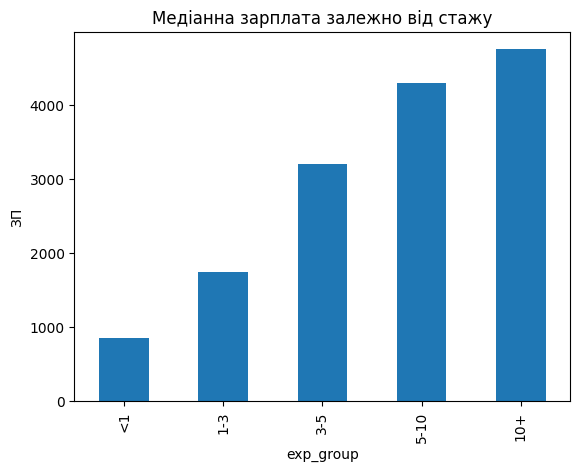

In [39]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

def parse_experience(exp):
    if pd.isna(exp):
        return np.nan
    exp = str(exp).lower().strip()
    if "менше" in exp:
        return 0.1
    if "пів" in exp:
        return 0.5
    exp = exp.replace(",", ".")
    number = re.findall(r"\d+\.?\d*", exp)
    if number:
        return float(number[0])

    return np.nan

df["exp_years"] = df["Загальний стаж роботи за спеціальністю"].apply(parse_experience)

print("Опис стажу:")
print(df["exp_years"].describe())
bins = [0, 1, 3, 5, 10, 50]
labels = ["<1", "1-3", "3-5", "5-10", "10+"]

df["exp_group"] = pd.cut(df["exp_years"], bins=bins, labels=labels)
exp_salary = df.groupby("exp_group", observed=False)["Зарплата у $$$ за місяць, лише ставка після сплати податків"].median()
print("\nМедіанна зарплата по стажу:")
print(exp_salary)

exp_salary.plot(kind="bar", title="Медіанна зарплата залежно від стажу")
plt.ylabel("ЗП")
plt.show()

Далі тут можна зробити багато аналогічних агрегацій, проаналізувати, в який час люди заповнювали форму, хто більше отримує, Business Analyst, чи Data Analyst. Я вас заохочувати не стримувати свій інтерес і покапати ці дані далі :)

In [40]:
df["Ваша посада4"].unique()


array([nan, 'Business Analyst', 'System Analyst', 'Data Analyst',
       'Product Analyst', 'BI Analyst'], dtype=object)

Кількість записів:
role_group
Business Analyst    289
Data Analyst        106
Name: count, dtype: int64

Статистика зарплат:
                  count         mean  median
role_group                                  
Business Analyst    289  2510.325260  2250.0
Data Analyst        106  1770.660377  1500.0


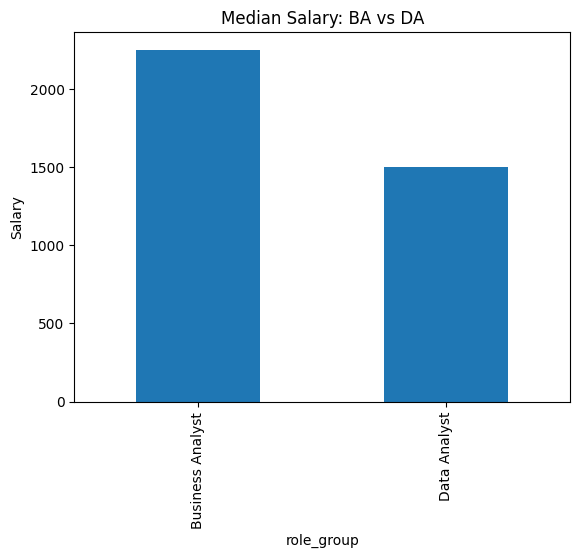

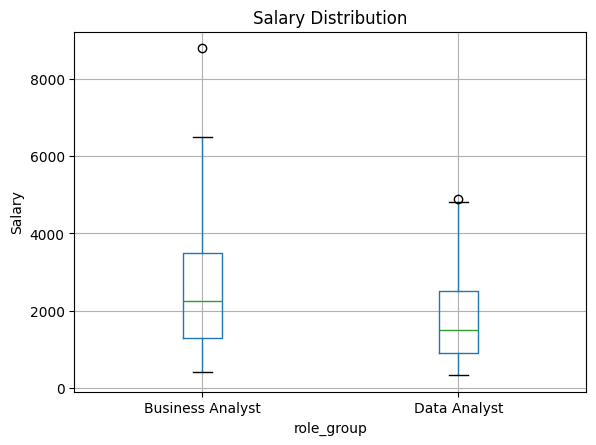

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
df.columns = df.columns.str.strip()
df["Ваша посада4"] = df["Ваша посада4"].astype(str).str.strip().str.lower()
def classify_role(title):
    if "business" in title:
        return "Business Analyst"
    elif "data" in title:
        return "Data Analyst"
    else:
        return None

df["role_group"] = df["Ваша посада4"].apply(classify_role)
subset = df[df["role_group"].notna()]
print("Кількість записів:")
print(subset["role_group"].value_counts())
salary_col = "Зарплата у $$$ за місяць, лише ставка після сплати податків"

stats = subset.groupby("role_group", observed=False)[salary_col]\
    .agg(["count", "mean", "median"])

print("\nСтатистика зарплат:")
print(stats)
subset.groupby("role_group", observed=False)[salary_col]\
    .median()\
    .plot(kind="bar", title="Median Salary: BA vs DA")

plt.ylabel("Salary")
plt.show()
subset.boxplot(column=salary_col, by="role_group")
plt.title("Salary Distribution")
plt.suptitle("")
plt.ylabel("Salary")
plt.show()